## Loan Approval

* EDA

In [2]:
##Importing all Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [3]:
##Load the dataset
df=pd.read_csv('loan_data.csv')
plt.style.use('dark_background')

In [4]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [6]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [7]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


<Axes: xlabel='person_age', ylabel='Count'>

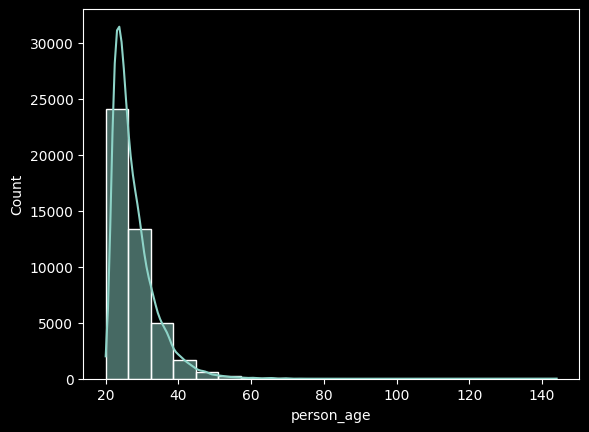

In [8]:
sns.histplot(df['person_age'],kde=True,bins=20)

<Axes: >

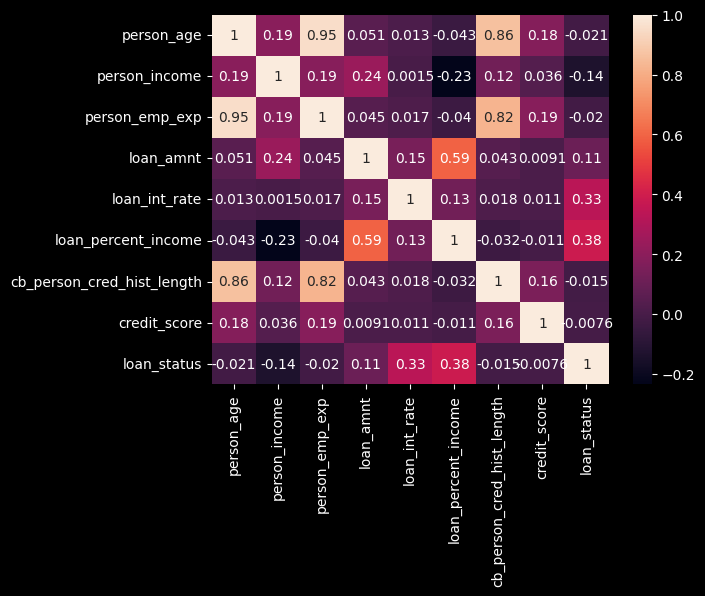

In [9]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

* Cleaning Data

In [10]:
df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [12]:
##Finding outliers using IQR
##Finding the 25 percentile
Num_key=['person_age','person_income','person_emp_exp','loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score']

Q1={}
for i  in Num_key:
    Q1[i]=np.percentile(df[i],25).round(2)

Q1

{'person_age': np.float64(24.0),
 'person_income': np.float64(47204.0),
 'person_emp_exp': np.float64(1.0),
 'loan_amnt': np.float64(5000.0),
 'loan_int_rate': np.float64(8.59),
 'loan_percent_income': np.float64(0.07),
 'cb_person_cred_hist_length': np.float64(3.0),
 'credit_score': np.float64(601.0)}

In [13]:
Q3={}
for i  in Num_key:
    Q3[i]=np.percentile(df[i],75).round(2)

Q3

{'person_age': np.float64(30.0),
 'person_income': np.float64(95789.25),
 'person_emp_exp': np.float64(8.0),
 'loan_amnt': np.float64(12237.25),
 'loan_int_rate': np.float64(12.99),
 'loan_percent_income': np.float64(0.19),
 'cb_person_cred_hist_length': np.float64(8.0),
 'credit_score': np.float64(670.0)}

In [14]:
IQR={}
for i  in Num_key:
    IQR[i]=int(Q3[i])-int(Q1[i])

IQR

{'person_age': 6,
 'person_income': 48585,
 'person_emp_exp': 7,
 'loan_amnt': 7237,
 'loan_int_rate': 4,
 'loan_percent_income': 0,
 'cb_person_cred_hist_length': 5,
 'credit_score': 69}

In [15]:
UF={}
LF={}
for i  in Num_key:
    UF[i]=(int(Q3[i])+(1.5*int(IQR[i])))
UF

{'person_age': 39.0,
 'person_income': 168666.5,
 'person_emp_exp': 18.5,
 'loan_amnt': 23092.5,
 'loan_int_rate': 18.0,
 'loan_percent_income': 0.0,
 'cb_person_cred_hist_length': 15.5,
 'credit_score': 773.5}

In [16]:
for i in Num_key:
    LF[i]=(int(Q1[i])-(1.5*int(IQR[i])))

LF

{'person_age': 15.0,
 'person_income': -25673.5,
 'person_emp_exp': -9.5,
 'loan_amnt': -5855.5,
 'loan_int_rate': 2.0,
 'loan_percent_income': 0.0,
 'cb_person_cred_hist_length': -4.5,
 'credit_score': 497.5}

In [17]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756,0.222222
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865,0.415744
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000,0.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000,0.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000,0.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000,0.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000,1.000000


In [18]:
Col_key=['person_age','person_income','person_emp_exp','loan_amnt',
       'loan_int_rate', 'cb_person_cred_hist_length',
       'credit_score']
for i in Col_key:
    df=df[(df[i]<UF[i]) & (df[i]>LF[i])]
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
5,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1
9,21.0,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3.0,640,No,1
11,21.0,female,Associate,13113.0,0,OWN,4500.0,HOMEIMPROVEMENT,8.63,0.34,2.0,651,No,1


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37602 entries, 1 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      37602 non-null  float64
 1   person_gender                   37602 non-null  object 
 2   person_education                37602 non-null  object 
 3   person_income                   37602 non-null  float64
 4   person_emp_exp                  37602 non-null  int64  
 5   person_home_ownership           37602 non-null  object 
 6   loan_amnt                       37602 non-null  float64
 7   loan_intent                     37602 non-null  object 
 8   loan_int_rate                   37602 non-null  float64
 9   loan_percent_income             37602 non-null  float64
 10  cb_person_cred_hist_length      37602 non-null  float64
 11  credit_score                    37602 non-null  int64  
 12  previous_loan_defaults_on_file  37602

In [20]:
df.describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status
count,37602.000000,37602.000000,37602.000000,37602.000000,37602.000000,37602.000000,37602.000000,37602.000000,37602.00000
mean,26.536886,69180.538668,4.204590,8502.982581,10.850191,0.137882,5.127094,632.430642,0.21709
std,4.008094,31662.991675,4.043325,4913.914497,2.862855,0.083633,2.839199,47.663626,0.41227
min,20.000000,8000.000000,0.000000,500.000000,5.420000,0.010000,2.000000,498.000000,0.00000
25%,23.000000,44702.750000,1.000000,4997.500000,8.490000,0.080000,3.000000,601.000000,0.00000
50%,26.000000,63425.500000,3.000000,7500.000000,11.010000,0.120000,4.000000,639.000000,0.00000
75%,29.000000,87500.250000,7.000000,12000.000000,12.870000,0.180000,7.000000,668.000000,0.00000
max,38.000000,168633.000000,18.000000,23000.000000,17.990000,0.660000,15.000000,762.000000,1.00000


* Data Preprocessing


In [21]:
##Checking distinct values in catagorical data
df['person_gender'].value_counts()

person_gender
male      20603
female    16999
Name: count, dtype: int64

In [22]:
df['loan_intent'].value_counts()

loan_intent
EDUCATION            7813
MEDICAL              7275
VENTURE              6582
PERSONAL             6193
DEBTCONSOLIDATION    5935
HOMEIMPROVEMENT      3804
Name: count, dtype: int64

In [23]:
df['person_home_ownership'].value_counts()

person_home_ownership
RENT        20497
MORTGAGE    14545
OWN          2466
OTHER          94
Name: count, dtype: int64

In [24]:
df['previous_loan_defaults_on_file'].value_counts()

previous_loan_defaults_on_file
Yes    19306
No     18296
Name: count, dtype: int64

In [25]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
5,21.0,female,High School,12951.0,0,OWN,2500.0,VENTURE,7.14,0.19,2.0,532,No,1
9,21.0,female,High School,12739.0,0,OWN,1600.0,VENTURE,14.74,0.13,3.0,640,No,1
11,21.0,female,Associate,13113.0,0,OWN,4500.0,HOMEIMPROVEMENT,8.63,0.34,2.0,651,No,1


In [26]:
df['person_education'].value_counts()

person_education
Bachelor       11619
Associate       9851
High School     9732
Master          5995
Doctorate        405
Name: count, dtype: int64

In [27]:
df=pd.get_dummies(data=df,columns=['previous_loan_defaults_on_file','person_home_ownership','loan_intent','person_gender','person_education'],drop_first=True)
df

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,previous_loan_defaults_on_file_Yes,...,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,person_gender_male,person_education_Bachelor,person_education_Doctorate,person_education_High School,person_education_Master
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0,True,...,True,False,False,False,False,False,False,False,True,False
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,1,False,...,False,False,True,False,False,False,False,False,True,False
5,21.0,12951.0,0,2500.0,7.14,0.19,2.0,532,1,False,...,False,False,False,False,True,False,False,False,True,False
9,21.0,12739.0,0,1600.0,14.74,0.13,3.0,640,1,False,...,False,False,False,False,True,False,False,False,True,False
11,21.0,13113.0,0,4500.0,8.63,0.34,2.0,651,1,False,...,False,True,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,47971.0,6,15000.0,15.66,0.31,3.0,645,1,False,...,False,False,True,False,False,True,False,False,False,False
44996,37.0,65800.0,17,9000.0,14.07,0.14,11.0,621,1,False,...,False,True,False,False,False,False,False,False,False,False
44997,33.0,56942.0,7,2771.0,10.02,0.05,10.0,668,1,False,...,False,False,False,False,False,True,False,False,False,False
44998,29.0,33164.0,4,12000.0,13.23,0.36,6.0,604,1,False,...,True,False,False,False,False,True,True,False,False,False


In [28]:
df[['previous_loan_defaults_on_file_Yes','loan_intent_EDUCATION','loan_intent_HOMEIMPROVEMENT','loan_intent_MEDICAL','loan_intent_PERSONAL','loan_intent_VENTURE','person_gender_male','person_education_Bachelor','person_education_Doctorate','person_education_High School','person_education_Master']]=df[['previous_loan_defaults_on_file_Yes','loan_intent_EDUCATION','loan_intent_HOMEIMPROVEMENT','loan_intent_MEDICAL','loan_intent_PERSONAL','loan_intent_VENTURE','person_gender_male','person_education_Bachelor','person_education_Doctorate','person_education_High School','person_education_Master']].astype(int)

In [29]:
df.columns

Index(['person_age', 'person_income', 'person_emp_exp', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'loan_status', 'previous_loan_defaults_on_file_Yes',
       'person_home_ownership_OTHER', 'person_home_ownership_OWN',
       'person_home_ownership_RENT', 'loan_intent_EDUCATION',
       'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL',
       'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'person_gender_male',
       'person_education_Bachelor', 'person_education_Doctorate',
       'person_education_High School', 'person_education_Master'],
      dtype='object')

In [30]:
df

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,previous_loan_defaults_on_file_Yes,...,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,person_gender_male,person_education_Bachelor,person_education_Doctorate,person_education_High School,person_education_Master
1,21.0,12282.0,0,1000.0,11.14,0.08,2.0,504,0,1,...,1,0,0,0,0,0,0,0,1,0
2,25.0,12438.0,3,5500.0,12.87,0.44,3.0,635,1,0,...,0,0,1,0,0,0,0,0,1,0
5,21.0,12951.0,0,2500.0,7.14,0.19,2.0,532,1,0,...,0,0,0,0,1,0,0,0,1,0
9,21.0,12739.0,0,1600.0,14.74,0.13,3.0,640,1,0,...,0,0,0,0,1,0,0,0,1,0
11,21.0,13113.0,0,4500.0,8.63,0.34,2.0,651,1,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,47971.0,6,15000.0,15.66,0.31,3.0,645,1,0,...,0,0,1,0,0,1,0,0,0,0
44996,37.0,65800.0,17,9000.0,14.07,0.14,11.0,621,1,0,...,0,1,0,0,0,0,0,0,0,0
44997,33.0,56942.0,7,2771.0,10.02,0.05,10.0,668,1,0,...,0,0,0,0,0,1,0,0,0,0
44998,29.0,33164.0,4,12000.0,13.23,0.36,6.0,604,1,0,...,1,0,0,0,0,1,1,0,0,0


* Data Standardization

In [31]:
from sklearn.preprocessing import StandardScaler
Num_key=['person_age','person_income','person_emp_exp','loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score']
scaler=StandardScaler()
df[Num_key]=scaler.fit_transform(df[Num_key])

In [32]:
df

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,loan_status,previous_loan_defaults_on_file_Yes,...,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,person_gender_male,person_education_Bachelor,person_education_Doctorate,person_education_High School,person_education_Master
1,-1.381444,-1.797028,-1.039898,-1.526905,0.101232,-0.692102,-1.101415,-2.694557,0,1,...,1,0,0,0,0,0,0,0,1,0
2,-0.383451,-1.792101,-0.297925,-0.611126,0.705532,3.612478,-0.749198,0.053907,1,0,...,0,0,1,0,0,0,0,0,1,0
5,-1.381444,-1.775899,-1.039898,-1.221646,-1.295993,0.623186,-1.101415,-2.107099,1,0,...,0,0,0,0,1,0,0,0,1,0
9,-1.381444,-1.782595,-1.039898,-1.404801,1.358735,-0.094244,-0.749198,0.158810,1,0,...,0,0,0,0,1,0,0,0,1,0
11,-1.381444,-1.770783,-1.039898,-0.814633,-0.775527,2.416761,-1.101415,0.389597,1,0,...,0,1,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,0.115546,-0.669862,0.444049,1.322185,1.680097,2.058046,-0.749198,0.263713,1,0,...,0,0,1,0,0,1,0,0,0,0
44996,2.610530,-0.106768,3.164618,0.101146,1.124700,0.025328,2.068535,-0.239822,1,0,...,0,1,0,0,0,0,0,0,0,0
44997,1.612537,-0.386530,0.691373,-1.166495,-0.289991,-1.050817,1.716319,0.746268,1,0,...,0,0,0,0,0,1,0,0,0,0
44998,0.614543,-1.137512,-0.050600,0.711666,0.831282,2.655905,0.307452,-0.596493,1,0,...,1,0,0,0,0,1,1,0,0,0


* Models

In [33]:
##Importing Model Algorithms 
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

In [34]:
##Training the models
from sklearn.model_selection import train_test_split
##for finding its accuracy and parameters
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report,f1_score,recall_score

In [35]:
x=df.drop(columns=['loan_status'])
y=df['loan_status']
X_train, X_test, y_train, y_test = train_test_split( x, y, test_size=0.20, random_state=42)

In [36]:
models={
    'Logistic Regression':LogisticRegression(),
    'KNN':KNeighborsClassifier(),
    'Naive Bayes':GaussianNB(),
    'Tree':DecisionTreeClassifier(),
    'SVM':SVC()
}

In [37]:
result=[]

In [38]:
##Fitting the model on the training data 
for name,model in models.items():
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    acc=accuracy_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    Recall=recall_score(y_test,y_pred)
    result.append({'model':name,
                   'Accuracy':round(acc,4),
                   'F1 Score':round(f1,4),
                   'Recall':round(Recall,4)
                   })

In [39]:
result
##SVM Gives the highest 

[{'model': 'Logistic Regression',
  'Accuracy': 0.896,
  'F1 Score': 0.7492,
  'Recall': 0.7268},
 {'model': 'KNN', 'Accuracy': 0.8976, 'F1 Score': 0.7413, 'Recall': 0.6864},
 {'model': 'Naive Bayes',
  'Accuracy': 0.7484,
  'F1 Score': 0.6246,
  'Recall': 0.9795},
 {'model': 'Tree', 'Accuracy': 0.9021, 'F1 Score': 0.7709, 'Recall': 0.7704},
 {'model': 'SVM', 'Accuracy': 0.916, 'F1 Score': 0.7902, 'Recall': 0.7405}]

In [40]:
import joblib
joblib.dump(models['Naive Bayes'],'Naive_Loan.pkl')
joblib.dump(scaler,'scaler.pkl')
joblib.dump(x.columns.tolist(),'columns.pkl')

['columns.pkl']